<a href="https://colab.research.google.com/github/YolandaZhao10/CSCI-6170-Project-in-AI-and-ML/blob/main/hw4/homework_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
# 1. Clone nanoGPT and install dependencies
!git clone https://github.com/karpathy/nanoGPT
%cd nanoGPT
!pip install tiktoken

# 2. Prepare the character-level Shakespeare dataset
!python data/shakespeare_char/prepare.py

import torch
import torch.nn as nn
import numpy as np
import os
import pickle
import random

# Record environment for requirements
print(f"GPU: {torch.cuda.get_device_name(0)}")
!pip list | grep -E "torch|numpy|tiktoken"


# seed setup
SEED = 42
def seed_all(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_all(SEED)

Cloning into 'nanoGPT'...
remote: Enumerating objects: 689, done.
remote: Total 689 (delta 0), reused 0 (delta 0), pack-reused 689 (from 1)
Receiving objects: 100% (689/689), 975.24 KiB | 4.19 MiB/s, done.
Resolving deltas: 100% (382/382), done.
/content/nanoGPT/nanoGPT/nanoGPT
length of dataset in characters: 1,115,394
all the unique characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
vocab size: 65
train has 1,003,854 tokens
val has 111,540 tokens
GPU: NVIDIA A100-SXM4-40GB
numpy                                    2.0.2
tiktoken                                 0.12.0
torch                                    2.10.0+cu128
torchao                                  0.10.0
torchaudio                               2.10.0+cu128
torchcodec                               0.10.0+cu128
torchdata                                0.11.0
torchsummary                             1.5.1
torchtune                                0.6.1
torchvision                              0.25.

# Task 1: Language Modeling - Part A

In [28]:
#Tiny Shakespeare dataset
!python data/shakespeare_char/prepare.py

length of dataset in characters: 1,115,394
all the unique characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
vocab size: 65
train has 1,003,854 tokens
val has 111,540 tokens


In [29]:
num_train_tokens = 1003854
batch_size = 64
block_size = 256
steps_per_epoch = np.floor(num_train_tokens/(batch_size*block_size)).astype(int)
print(steps_per_epoch)

61


In [30]:
import subprocess
import textwrap

runs = {
    "5_epochs": steps_per_epoch*5,
    "50_epochs": steps_per_epoch*50,
    "500_epochs": steps_per_epoch*500,
}

base_config = """
eval_interval = 100
eval_iters = 200
log_interval = 10
always_save_checkpoint = True

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256

n_layer = 4
n_head = 4
n_embd = 128
dropout = 0.2

learning_rate = 1e-3
lr_decay_iters = {max_iters}
max_iters = {max_iters}
min_lr = 1e-4
beta2 = 0.99

warmup_iters = 100
device = 'cuda'
compile = False
out_dir = '{out_dir}'
"""

os.makedirs("logs", exist_ok=True)

for label, max_iters in runs.items():
    out_dir = f"out_{label}"
    config_path = f"config/train_{label}.py"
    log_path = f"logs/train_{label}.log"

    config_now = base_config.format(max_iters=max_iters, out_dir=out_dir)
    with open(config_path, "w") as f:
        f.write(config_now)

    print(f"\n===== Training {label} ({max_iters} iterations) =====")

    cmd = [
        "python", "train.py", config_path,
        "--device=cuda",
        "--compile=False"
    ]

    with open(log_path, "w") as logfile:
        process = subprocess.Popen(
            cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True
        )
        for line in process.stdout:
            print(line, end="")
            logfile.write(line)
        process.wait()

print("\nAll three runs finished.")


===== Training 5_epochs (305 iterations) =====
/content/nanoGPT/nanoGPT/nanoGPT/train.py:196: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))
Overriding config with config/train_5_epochs.py:

eval_interval = 100
eval_iters = 200
log_interval = 10
always_save_checkpoint = True

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256

n_layer = 4
n_head = 4
n_embd = 128
dropout = 0.2

learning_rate = 1e-3
lr_decay_iters = 305
max_iters = 305
min_lr = 1e-4
beta2 = 0.99

warmup_iters = 100
device = 'cuda'
compile = False
out_dir = 'out_5_epochs'

Overriding: device = cuda
Overriding: compile = False
tokens per iteration will be: 16,384
found vocab_size = 65 (inside data/shakespeare_char/meta.pkl)
Initializing a new model from scratch
number of parameters: 0.80M
num decayed parameter tensors: 18, with 827,520

A PyTorch deprecation warning appeared due to newer AMP APIs in Colab, but it did not affect training.

In [31]:
import subprocess
sample_outputs = {}

for label in ["5_epochs", "50_epochs", "500_epochs"]:
    out_dir = f"out_{label}"
    sample_file = f"sample_{label}.txt"

    cmd = [
        "python", "sample.py",
        "--out_dir=" + out_dir,
        "--start=Love:",
        "--seed=42",
        "--num_samples=1",
        "--max_new_tokens=800"
    ]

    with open(sample_file, "w") as f:
        subprocess.run(cmd, stdout=f, stderr=subprocess.STDOUT, text=True)

    with open(sample_file, "r") as f:
        content = f.read()

    # Clean common extra output text
    clean_text = content
    if "Love:" in clean_text:
        clean_text = clean_text[clean_text.find("Love:"):].strip()

    sample_outputs[label] = clean_text

for label, text in sample_outputs.items():
    print("\n" + "=" * 70)
    print(label.upper())
    print("=" * 70)
    print(text)


5_EPOCHS
Love:
Overriding: seed = 42
Overriding: num_samples = 1
Overriding: max_new_tokens = 800
number of parameters: 0.80M
Loading meta from data/shakespeare_char/meta.pkl...
Love:
Fit anof te thithe gotheared tharnd he,
An ckn,
Ofenoume o--wishelap wist cald s, orean,
The muprthand ainde e y d that mang yofowhas
Thourangean t thal hathant me machan th haisthe ind wisthurore cense wince me, wouss thee?
Thitorest 's m; hy, we I he wours winthof ind s heve she, sthiran thanessamy o at's lore wend d phisepe mue thil osonoureearunghimyor g y atharinthed an te s mire akns the p'es nd nowe bs oure we,
Bur manase Ve on my foristhatessotin,
Fof I maripakn t eand be, g duthintine.
ASTI tored ve y ube I thellurs meane asisy hapout thi,
Sthong sto;
Pond se tare.


UCENERS:
LUMes,
He tinather pre be bo avinthinsiour wad br t, ardset
Thin plear he, are len me buichead ENomayoncer alou se myo me hathe, sperifive l Ifon; mer thee yos
I nomers we anf mino dind dissue omollomspe p f
---------------

In [32]:
import re

val_pattern = re.compile(r"step (\d+): train loss ([\d\.]+), val loss ([\d\.]+)")
train_pattern = re.compile(r"iter (\d+): loss ([\d\.]+)")

summary = {}

for label in ["5_epochs", "50_epochs", "500_epochs"]:
    log_path = f"logs/train_{label}.log"

    last_train = None
    last_val = None

    with open(log_path, "r") as f:
        for line in f:
            m1 = train_pattern.search(line)
            if m1:
                last_train = (int(m1.group(1)), float(m1.group(2)))

            m2 = val_pattern.search(line)
            if m2:
                last_val = (int(m2.group(1)), float(m2.group(2)), float(m2.group(3)))

    summary[label] = {
        "last_train": last_train,
        "last_val": last_val
    }

for label, result in summary.items():
    print(f"\n{label}")
    print("last train:", result["last_train"])
    print("last val:", result["last_val"])


5_epochs
last train: (300, 2.44)
last val: (300, 2.4101, 2.4152)

50_epochs
last train: (3050, 1.597)
last val: (3000, 1.4758, 1.6765)

500_epochs
last train: (30500, 1.2673)
last val: (30500, 1.1597, 1.4471)


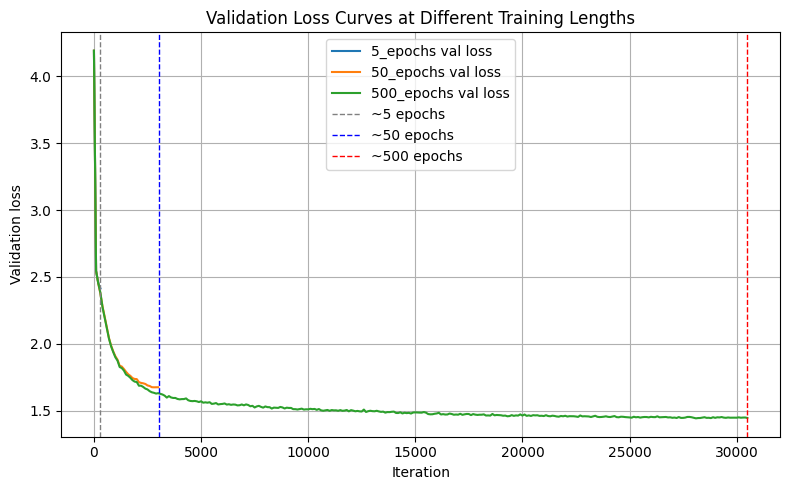

In [33]:
import matplotlib.pyplot as plt
import re

val_pattern = re.compile(r"step (\d+): train loss ([\d\.]+), val loss ([\d\.]+)")

plt.figure(figsize=(8, 5))

for label in ["5_epochs", "50_epochs", "500_epochs"]:
    log_path = f"logs/train_{label}.log"
    steps = []
    vals = []

    with open(log_path, "r") as f:
        for line in f:
            m = val_pattern.search(line)
            if m:
                steps.append(int(m.group(1)))
                vals.append(float(m.group(3)))

    if steps:
        plt.plot(steps, vals, label=f"{label} val loss")

# vertical lines for epoch checkpoints
plt.axvline(x=steps_per_epoch*5, color='gray', linestyle='--', linewidth=1, label='~5 epochs')
plt.axvline(x=steps_per_epoch*50, color='blue', linestyle='--', linewidth=1, label='~50 epochs')
plt.axvline(x=steps_per_epoch*500, color='red', linestyle='--', linewidth=1, label='~500 epochs')

plt.xlabel("Iteration")
plt.ylabel("Validation loss")
plt.title("Validation Loss Curves at Different Training Lengths")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("loss_curve_three_runs.png", dpi=200)
plt.show()

# Task 1: Language Modeling - Part B

In [34]:
import os
import pickle
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Hyperparameters
block_size = 256
batch_size = 64
embed_size = 128
hidden_size = 256
n_layers = 2
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load data
data_dir = 'data/shakespeare_char'
train_data = np.fromfile(os.path.join(data_dir, 'train.bin'), dtype=np.uint16)
val_data = np.fromfile(os.path.join(data_dir, 'val.bin'), dtype=np.uint16)

def get_batch(split):
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([
        torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix
    ])
    y = torch.stack([
        torch.from_numpy((data[i+1:i+block_size+1]).astype(np.int64)) for i in ix
    ])
    return x.to(device), y.to(device)

# Load metadata
with open(os.path.join(data_dir, 'meta.pkl'), 'rb') as f:
    meta = pickle.load(f)

vocab_size = meta['vocab_size']
stoi, itos = meta['stoi'], meta['itos']

class ShakespeareLSTM(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(
            embed_size,
            hidden_size,
            n_layers,
            batch_first=True,
            dropout=0.2 if n_layers > 1 else 0
        )
        self.linear = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        embeds = self.embedding(x)
        out, hidden = self.lstm(embeds, hidden)
        logits = self.linear(out)
        return logits, hidden

model = ShakespeareLSTM(vocab_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

checkpoints = [5, 50, 500]
history = {'train': [], 'val': [], 'steps': []}

def estimate_loss(model, eval_iters=50):
    model.eval()
    results = {}
    with torch.no_grad():
        for split in ['train', 'val']:
            losses = []
            for _ in range(eval_iters):
                xb, yb = get_batch(split)
                logits, _ = model(xb)
                loss = criterion(logits.view(-1, vocab_size), yb.view(-1))
                losses.append(loss.item())
            results[split] = sum(losses) / len(losses)
    model.train()
    return results

def generate(model, start_str="Love:", max_len=800):
    model.eval()
    chars = [stoi[c] for c in start_str]
    input_seq = torch.tensor(chars, dtype=torch.long).unsqueeze(0).to(device)
    hidden = None
    output = start_str

    with torch.no_grad():
        for _ in range(max_len):
            logits, hidden = model(input_seq, hidden)
            last_logit = logits[:, -1, :]
            probs = torch.softmax(last_logit, dim=-1)
            next_char_idx = torch.multinomial(probs, num_samples=1).item()
            output += itos[next_char_idx]
            input_seq = torch.tensor([[next_char_idx]], dtype=torch.long).to(device)

    return output

In [35]:
# Training
current_step = 0
for epoch_target in checkpoints:
    target_step = epoch_target * steps_per_epoch
    print(f"\n--- Training to Epoch {epoch_target} (Step {target_step}) ---")

    model.train()
    while current_step < target_step:
        xb, yb = get_batch('train')
        logits, _ = model(xb)
        loss = criterion(logits.view(-1, vocab_size), yb.view(-1))

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        current_step += 1

        if current_step % 100 == 0 or current_step == target_step:
            losses = estimate_loss(model, eval_iters=50)
            history['train'].append(losses['train'])
            history['val'].append(losses['val'])
            history['steps'].append(current_step)
    print(f"step {current_step}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    print(f"\n--- Generating Sample for {epoch_target} Epochs (using start word 'Love:') ---")
    sample_text = generate(model, start_str="Love:", max_len=800)

    with open(f"lstm_sample_epoch_{epoch_target}.txt", "w") as f:
        f.write(sample_text)
    print(sample_text)


--- Training to Epoch 5 (Step 305) ---
step 305: train loss 1.7280, val loss 1.8370

--- Generating Sample for 5 Epochs (using start word 'Love:') ---
Love:
Ou as fiter, 'tn my thus modest;
Wolk, preckneur your fail with lapfiise.

KITHOS CINREPTAUY:
You, with, be ever followert, your hasterhing.

CADHAMLA:
Mathers me my handel have here to-fordurous canse wilch my seequs-
I'll word mest 'llame here and be lass oln!-
Which speet is there bron than seam, of that was we byd prienped
And not of so retalung. Who wend and wilt,
And hee sumfore instiln's'ws camnowed
Bvow now: thy Dortase be on my farily,
If sostile your many as Bose,
The wist unpinting. And frose, ally ubder theone from dich,
And bry do mi,
Stince sto; songue a are.

RUCIO:
Soy, very my pinath me: what bode and king,
Singer bit, and then in plucise
That Ill by hear hunder path!

MASINCA:
Mady, may bed I speen comely fay; me here-my,
Mistemers woranf, woo dinded ssue om
licts thou f

--- Training to Epoch 50 (Step 3050) ---


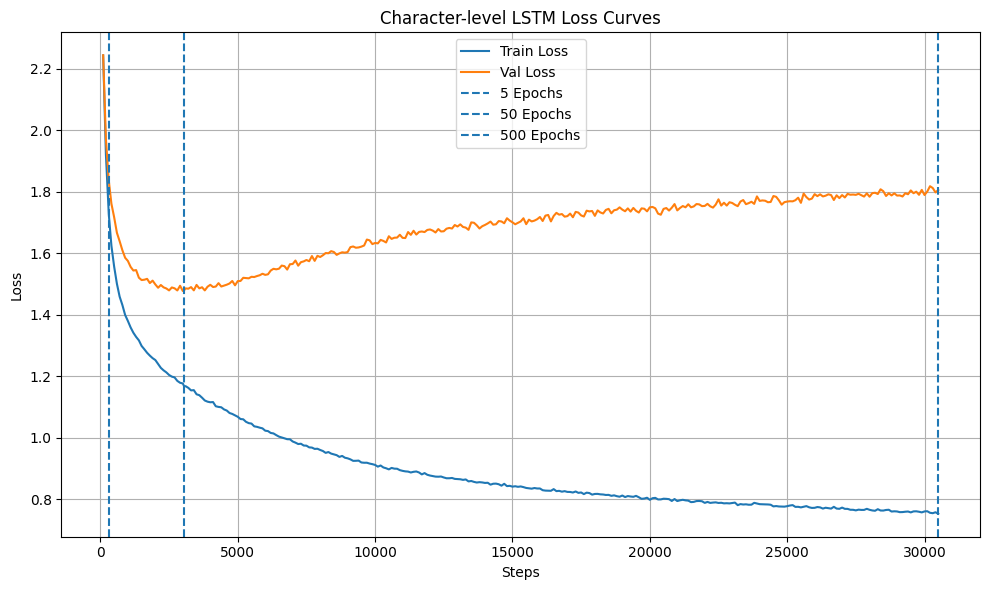

In [36]:
# Plot
plt.figure(figsize=(10, 6))
plt.plot(history['steps'], history['train'], label='Train Loss')
plt.plot(history['steps'], history['val'], label='Val Loss')

plt.axvline(x=5 * steps_per_epoch, linestyle='--', label='5 Epochs')
plt.axvline(x=50 * steps_per_epoch, linestyle='--', label='50 Epochs')
plt.axvline(x=500 * steps_per_epoch, linestyle='--', label='500 Epochs')

plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Character-level LSTM Loss Curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Task 1: Language Modeling - Part C

**GPT vs LSTM Comparison at Different Checkpoints**

### ~5 Epochs

**Coherence**

* **GPT:** Very low coherence; mostly random characters and incomplete words.
* **LSTM:** Slightly better coherence; some recognizable words and short phrases appear.

**Formatting**

* **GPT:** Dialogue-like formatting appears occasionally but is inconsistent.
* **LSTM:** Some speaker-style formatting (e.g., `CHARACTER:`) begins to appear earlier.

**Repetition Loops**

* **GPT:** Few repetition loops because the model has not yet learned stable patterns.
* **LSTM:** Also minimal repetition, but sequences sometimes repeat small fragments.

**Character / Word Structure**

* **GPT:** Many broken or misspelled words and unstable capitalization.
* **LSTM:** Words are slightly more recognizable and character combinations are more stable.

---

### ~50 Epochs

**Coherence**

* **GPT:** Noticeably improved coherence; text resembles dialogue with partial sentence structure.
* **LSTM:** Coherence improves but remains weaker than GPT; sentences are often awkward or incomplete.

**Formatting**

* **GPT:** Dialogue formatting becomes clearer with recognizable speaker names.
* **LSTM:** Dialogue structure appears but is less consistent.

**Repetition Loops**

* **GPT:** Repetition remains limited.
* **LSTM:** Some repeated phrases or patterns start appearing.

**Character / Word Structure**

* **GPT:** Word spelling improves and sentences become more readable.
* **LSTM:** Words are readable but grammar and phrasing remain inconsistent.

---

### ~500 Epochs

**Coherence**

* **GPT:** High coherence; sentences and dialogue structure are more stable and understandable.
* **LSTM:** Coherence decreases relative to GPT; text often becomes fragmented or awkward.

**Formatting**

* **GPT:** Dialogue formatting is consistent and resembles Shakespeare-style conversations.
* **LSTM:** Formatting becomes less stable and sometimes breaks dialogue structure.

**Repetition Loops**

* **GPT:** Very few repetition loops.
* **LSTM:** More repetition and awkward phrasing appear.

**Character / Word Structure**

* **GPT:** Words and sentence structure are mostly correct.
* **LSTM:** Words remain readable but grammar and phrasing degrade due to overfitting.

---

### Significant Difference Between the Models

**Architecture Difference**

* **GPT:** Uses **self-attention**, allowing each token to directly consider all previous tokens within the context window. This helps capture long-range dependencies and maintain consistent dialogue structure.
* **LSTM:** Uses **recurrence**, passing information sequentially through hidden states. Information can degrade over long sequences, making it harder to maintain global context.

**Training Behavior**

* **GPT:** Maintains better generalization and stability during longer training.
* **LSTM:** Shows signs of **overfitting** at later stages (training loss decreases while validation loss increases), which leads to weaker coherence and more repetition in generated text.


# Task 2: Sequence Modeling Project

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, GRU,
    Dense, Dropout, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

VOCAB_SIZE = 10000
MAX_LEN = 200
EMBED_DIM = 64
BATCH_SIZE = 64
EPOCHS = 8
VAL_SPLIT = 0.2


IMDB Movie Review Dataset

Source: https://ai.stanford.edu/~amaas/data/sentiment/

Sequence models are appropriate for IMDB sentiment classification because each review is an ordered sequence of words, and meaning depends on word order and context. For example, “good” and “not good” have different meanings although they share similar words. RNN-based models can process token sequences step by step and preserve context across positions.

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Original training samples: 25000
Original test samples: 25000
Train label distribution: [12500 12500]
Test label distribution: [12500 12500]
Train review length - min: 11 max: 2494 mean: 238.71364
Test review length - min: 7 max: 2315 mean: 230.8042


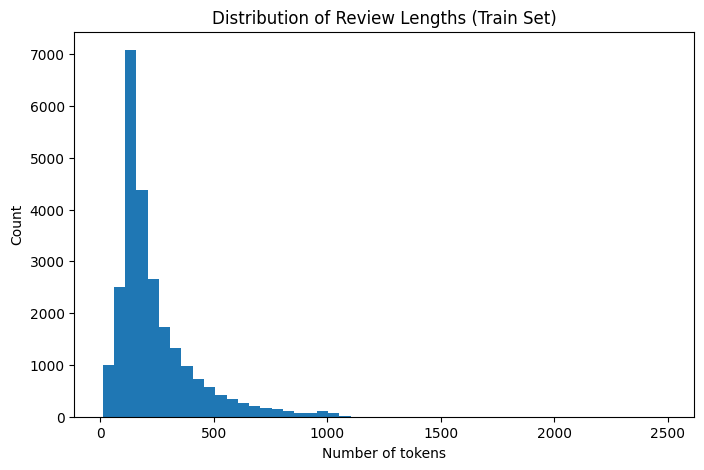

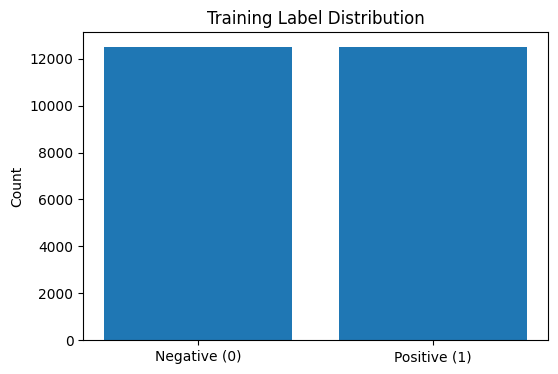

In [38]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print("Original training samples:", len(X_train))
print("Original test samples:", len(X_test))

train_lengths = [len(seq) for seq in X_train]
test_lengths = [len(seq) for seq in X_test]

print("Train label distribution:", np.bincount(y_train))
print("Test label distribution:", np.bincount(y_test))
print("Train review length - min:", np.min(train_lengths), "max:", np.max(train_lengths), "mean:", np.mean(train_lengths))
print("Test review length - min:", np.min(test_lengths), "max:", np.max(test_lengths), "mean:", np.mean(test_lengths))

plt.figure(figsize=(8, 5))
plt.hist(train_lengths, bins=50)
plt.title("Distribution of Review Lengths (Train Set)")
plt.xlabel("Number of tokens")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(["Negative (0)", "Positive (1)"], np.bincount(y_train))
plt.title("Training Label Distribution")
plt.ylabel("Count")
plt.show()

Reviews were integer-encoded using the Keras IMDB dataset loader, restricted to the top 10,000 most frequent words. Each review was padded or truncated to length 200 so that all samples had the same input size.

In [39]:
X_train_pad = pad_sequences(X_train, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test, maxlen=MAX_LEN, padding='post', truncating='post')

print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)

X_train_pad shape: (25000, 200)
X_test_pad shape: (25000, 200)


In [40]:
word_index = imdb.get_word_index()
index_to_word = {idx + 3: word for word, idx in word_index.items()}
index_to_word[0] = "<PAD>"
index_to_word[1] = "<START>"
index_to_word[2] = "<UNK>"
index_to_word[3] = "<UNUSED>"

def decode_review(encoded_review):
    return " ".join(index_to_word.get(i, "?") for i in encoded_review)

print(decode_review(X_train[0][:100]))
print("Label:", y_train[0])

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was
Label: 1


To evaluate the performance of the sequence models, I used several classification metrics: accuracy, precision, recall, and F1 score. Accuracy measures the proportion of correctly predicted reviews, while precision and recall provide additional insight into how well the model identifies positive sentiment. The F1 score, which is the harmonic mean of precision and recall, offers a balanced measure of performance, especially when evaluating classification quality beyond accuracy alone. During training, a validation set was created using a validation split of the training data. Validation loss and validation accuracy were monitored each epoch and visualized to observe the learning behavior of the model and detect potential overfitting. Additionally, early stopping was applied based on validation loss to stop training when the model stopped improving. After training was completed, the final performance of each model was evaluated on the test set, which was not used during training. The same metrics—accuracy, precision, recall, and F1 score—were computed on the test data to measure how well the model generalizes to unseen examples.

In [41]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_prob = model.predict(X_test, verbose=0)
    y_pred = (y_prob >= 0.5).astype(int).reshape(-1)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n=== {model_name} Test Results ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    }

def plot_history(history, title_prefix="Model"):
    plt.figure(figsize=(7, 5))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

def train_model(model, model_name):
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=2,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_pad, y_train,
        validation_split=VAL_SPLIT,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=1
    )

    model.summary()
    plot_history(history, model_name)
    metrics = evaluate_model(model, X_test_pad, y_test, model_name)

    return model, history, metrics

Basic RNN:
- Uses recurrent hidden states across time steps.
- Time-step activation: tanh
- Output activation: sigmoid

Basic RNN: Embedding layer (10000, 64) → SimpleRNN(64, tanh) → Dense(1, sigmoid)

LSTM:
- Uses gates to better preserve long-term information.
- Usually handles longer dependencies better than basic RNN.

LSTM: Embedding layer → LSTM(64, tanh) → Dense(1, sigmoid)

GRU:
- Similar idea to LSTM but simpler.
- Often trains faster while keeping strong performance.

GRU: Embedding layer → GRU(64, tanh) → Dense(1, sigmoid)

### Difference between all three models

The three sequence models showed clear performance differences. The basic RNN performed the worst, achieving accuracy close to random guessing. In contrast, both LSTM and GRU achieved much higher performance, with LSTM producing the best results among the recurrent models and GRU performing slightly worse but still significantly better than the basic RNN. These differences arise mainly from how each model handles long-term dependencies in sequences. A basic RNN updates its hidden state using a simple recurrent transformation, which often leads to the vanishing gradient problem during training. As a result, it struggles to retain information from earlier time steps, making it difficult to capture long-range relationships in text sequences. LSTM addresses this issue by introducing gating mechanisms (input, forget, and output gates) that control how information is stored, updated, and passed through time. These gates allow the model to preserve useful information over longer sequences, which improves performance on tasks like sentiment analysis. GRU also uses gating mechanisms, but with a simpler structure that combines some of the gates used in LSTM. This makes GRU computationally lighter and often faster to train, although in this experiment it performed slightly worse than LSTM. Overall, the improved ability of LSTM and GRU to manage long-term dependencies explains why they significantly outperform the basic RNN.

### Can you use a traditional feed-forward network? Why or why not?

Yes, a traditional feed-forward network can be used to solve the same problem if the sequential data is first converted into a fixed-size feature representation. In this project, the sequence of word tokens in each review was transformed into a fixed-length vector using an embedding layer followed by global average pooling, which aggregates the information from all tokens into a single representation. This fixed-size vector can then be used as input to a standard feed-forward neural network. However, unlike sequence models such as RNN, LSTM, and GRU, a feed-forward network does not explicitly model the order of words or temporal dependencies within the sequence. As a result, it may lose important contextual information, such as differences between phrases like “good” and “not good.” While feed-forward networks can still perform reasonably well when strong features are extracted from the sequence, sequence models are generally better suited for tasks where word order and long-range dependencies play an important role.


Feed-forward network:
- Can work after converting the sequence into a fixed-size representation.
- But it does not model word order as explicitly as RNN/LSTM/GRU.

Feed-forward baseline: Embedding layer → GlobalAveragePooling1D → Dense(64, relu) → Dropout(0.3) → Dense(1, sigmoid)


### Difference between all four models
The four models—Basic RNN, LSTM, GRU, and the feed-forward network—show notable differences in how they handle sequential information and in their overall performance. The Basic RNN performed the worst, with accuracy close to random guessing, indicating that it struggled to learn meaningful patterns from the text data. This is likely due to the vanishing gradient problem, which makes it difficult for basic RNNs to retain information from earlier time steps in long sequences. In contrast, LSTM performed much better, achieving high accuracy and F1 score. This improvement is due to its gating mechanisms (input, forget, and output gates) that allow the model to preserve important information across longer sequences and avoid vanishing gradients. GRU also significantly outperformed the basic RNN and produced strong results, although slightly lower than LSTM in this experiment. GRU simplifies the LSTM architecture by combining some gates, which makes it computationally more efficient and faster to train, but it may occasionally sacrifice a small amount of modeling flexibility. Interestingly, the feed-forward network achieved performance comparable to or slightly better than LSTM in this setup. This occurs because the model used embedding representations with global average pooling, which can capture strong sentiment-related word features even without explicitly modeling sequence order. However, unlike the recurrent models, the feed-forward network does not explicitly capture word order or temporal dependencies, so its effectiveness depends on how informative the extracted features are. Overall, LSTM and GRU demonstrate the advantages of sequence-aware architectures, while the feed-forward network shows that simpler models can still perform well when the task relies heavily on word-level signals rather than complex sequential structure.


Epoch 1/8


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.4959 - loss: 0.6960 - val_accuracy: 0.5150 - val_loss: 0.6926
Epoch 2/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6149 - loss: 0.6469 - val_accuracy: 0.5008 - val_loss: 0.7381
Epoch 3/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6759 - loss: 0.5252 - val_accuracy: 0.5076 - val_loss: 0.9043


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,944,965 (7.42 MB)

 Trainable params: 648,321 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,296,644 (4.95 MB)

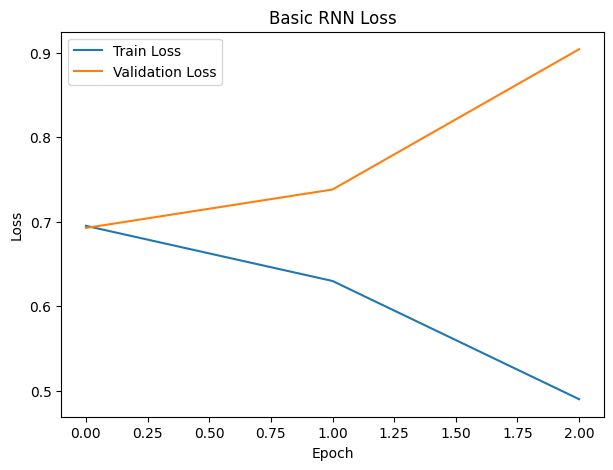

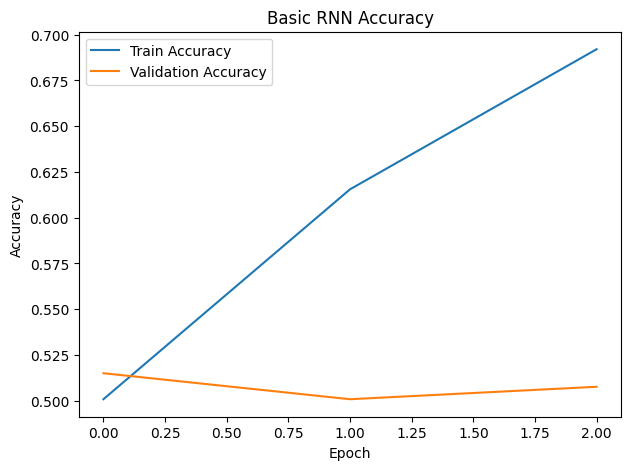


=== Basic RNN Test Results ===
Accuracy : 0.5000
Precision: 0.5000
Recall   : 0.1831
F1 Score : 0.2681
Confusion Matrix:
[[10211  2289]
 [10211  2289]]


In [42]:
# Build Basic RNN model
def build_simple_rnn():
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
        SimpleRNN(64, activation='tanh'),
        Dense(1, activation='sigmoid')
    ])
    return model

simple_rnn_model, simple_rnn_history, simple_rnn_metrics = train_model(
    build_simple_rnn(), "Basic RNN")

Epoch 1/8


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.5152 - loss: 0.6927 - val_accuracy: 0.6592 - val_loss: 0.6264
Epoch 2/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5789 - loss: 0.6723 - val_accuracy: 0.5486 - val_loss: 0.6760
Epoch 3/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6042 - loss: 0.6356 - val_accuracy: 0.5754 - val_loss: 0.6677


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,019,269 (7.70 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,346,180 (5.14 MB)

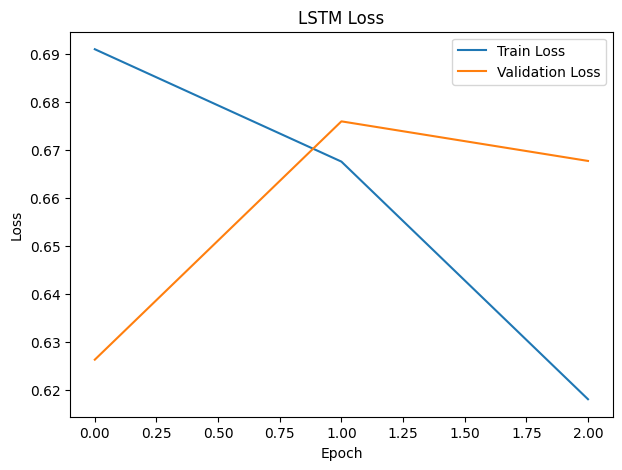

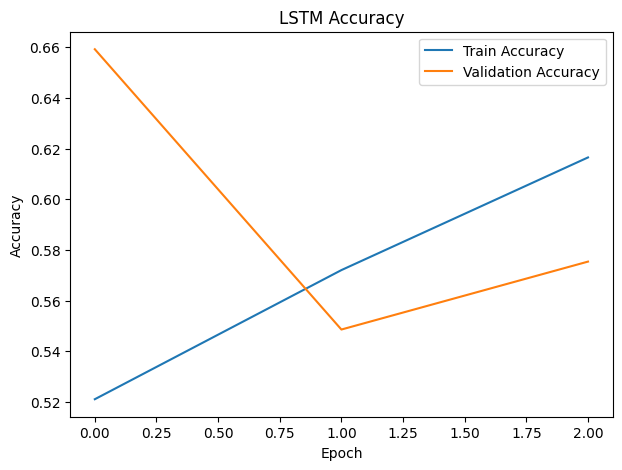


=== LSTM Test Results ===
Accuracy : 0.6380
Precision: 0.7290
Recall   : 0.4393
F1 Score : 0.5482
Confusion Matrix:
[[10459  2041]
 [ 7009  5491]]


In [43]:
# Build LSTM model
def build_lstm():
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
        LSTM(64, activation='tanh'),
        Dense(1, activation='sigmoid')
    ])
    return model

lstm_model, lstm_history, lstm_metrics = train_model(
    build_lstm(), "LSTM")

Epoch 1/8


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5126 - loss: 0.6931 - val_accuracy: 0.5410 - val_loss: 0.6856
Epoch 2/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6314 - loss: 0.6447 - val_accuracy: 0.7280 - val_loss: 0.5757
Epoch 3/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7513 - loss: 0.5384 - val_accuracy: 0.7448 - val_loss: 0.5359
Epoch 4/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7908 - loss: 0.4819 - val_accuracy: 0.7050 - val_loss: 0.5573
Epoch 5/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8070 - loss: 0.4355 - val_accuracy: 0.8192 - val_loss: 0.4298
Epoch 6/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8862 - loss: 0.2890 - val_accuracy: 0.8518 - val_loss: 0.3725
Epoch 7/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9235 - loss: 0.2073 - val_accuracy: 0.8516 - val_loss: 0.4087
Epoch 8/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9527 - loss: 0.1455 - val_accuracy: 0.8486 - val

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,995,077 (7.61 MB)

 Trainable params: 665,025 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,330,052 (5.07 MB)

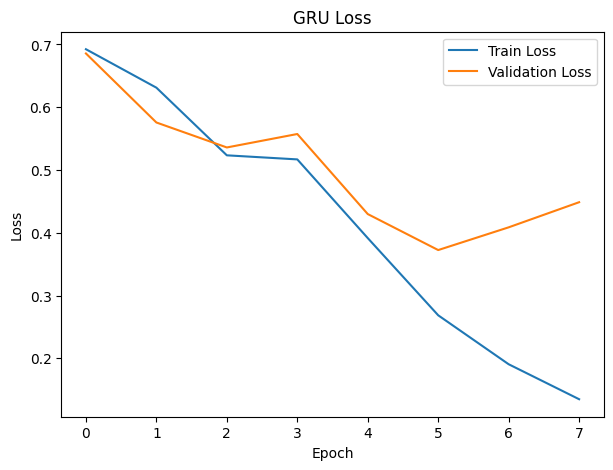

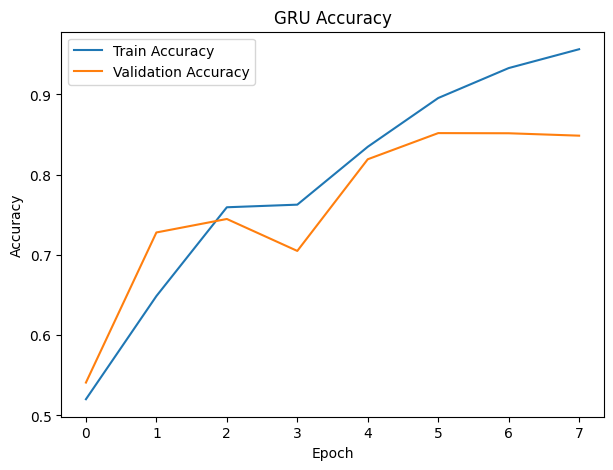


=== GRU Test Results ===
Accuracy : 0.8338
Precision: 0.8366
Recall   : 0.8297
F1 Score : 0.8331
Confusion Matrix:
[[10475  2025]
 [ 2129 10371]]


In [44]:
# Build GRU model
def build_gru():
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
        GRU(64, activation='tanh'),
        Dense(1, activation='sigmoid')
    ])
    return model

gru_model, gru_history, gru_metrics = train_model(
    build_gru(), "GRU")

Epoch 1/8


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.6308 - loss: 0.6329 - val_accuracy: 0.8550 - val_loss: 0.3585
Epoch 2/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8630 - loss: 0.3299 - val_accuracy: 0.8702 - val_loss: 0.3151
Epoch 3/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8994 - loss: 0.2558 - val_accuracy: 0.8750 - val_loss: 0.3133
Epoch 4/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9167 - loss: 0.2210 - val_accuracy: 0.8696 - val_loss: 0.3323
Epoch 5/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9328 - loss: 0.1876 - val_accuracy: 0.8694 - val_loss: 0.3476


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,932,677 (7.37 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,288,452 (4.92 MB)

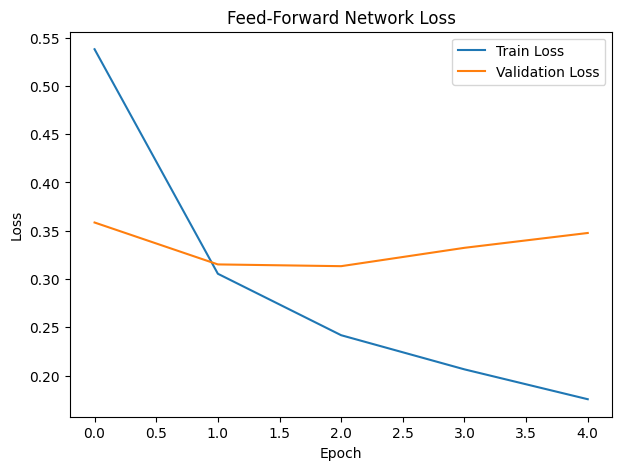

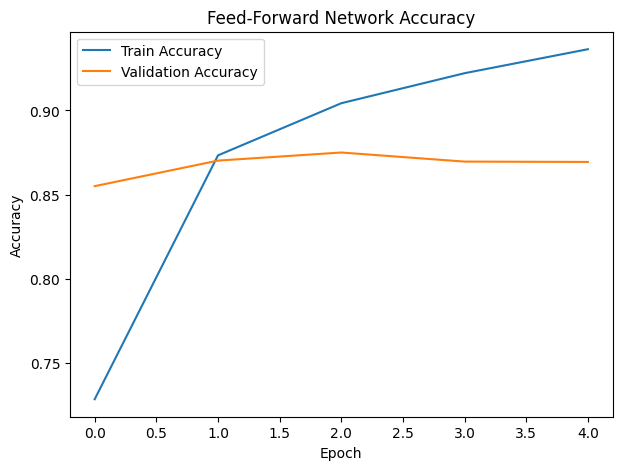


=== Feed-Forward Network Test Results ===
Accuracy : 0.8573
Precision: 0.8500
Recall   : 0.8678
F1 Score : 0.8588
Confusion Matrix:
[[10586  1914]
 [ 1653 10847]]


In [45]:
# Build feed-forward baseline
def build_feedforward():
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
        GlobalAveragePooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

ffn_model, ffn_history, ffn_metrics = train_model(
    build_feedforward(), "Feed-Forward Network")

In [46]:
all_results = [
    simple_rnn_metrics,
    lstm_metrics,
    gru_metrics,
    ffn_metrics
]

print("\nFinal Comparison")
for r in all_results:
    print(
        f"{r['Model']:<22}"
        f" Accuracy={r['Accuracy']:.4f}"
        f" Precision={r['Precision']:.4f}"
        f" Recall={r['Recall']:.4f}"
        f" F1={r['F1']:.4f}"
    )


Final Comparison
Basic RNN              Accuracy=0.5000 Precision=0.5000 Recall=0.1831 F1=0.2681
LSTM                   Accuracy=0.6380 Precision=0.7290 Recall=0.4393 F1=0.5482
GRU                    Accuracy=0.8338 Precision=0.8366 Recall=0.8297 F1=0.8331
Feed-Forward Network   Accuracy=0.8573 Precision=0.8500 Recall=0.8678 F1=0.8588


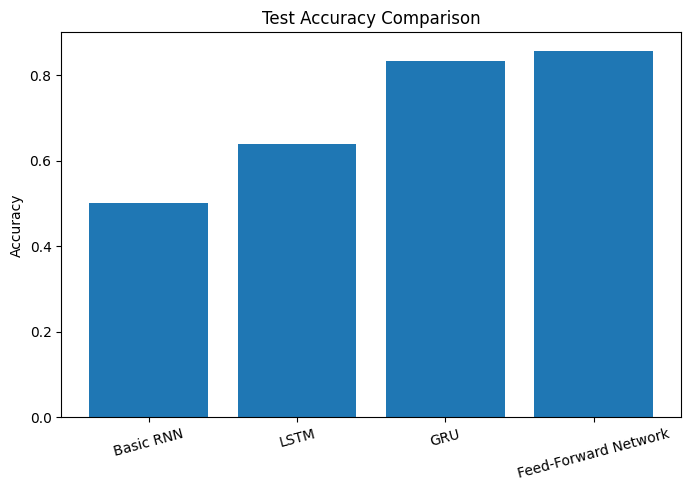

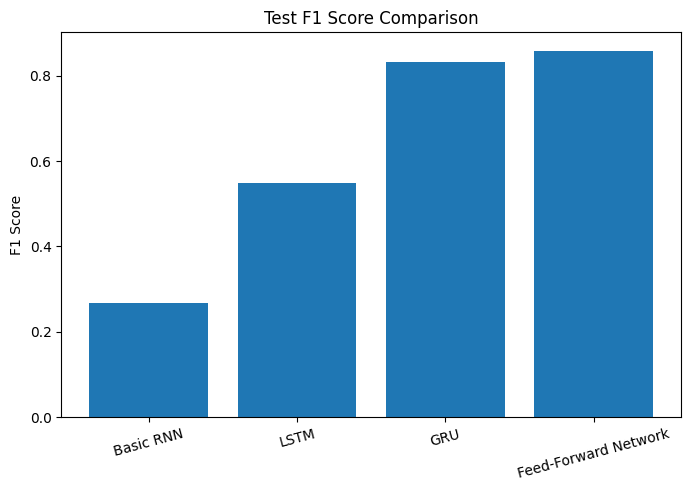

In [47]:
model_names = [r["Model"] for r in all_results]
acc_scores = [r["Accuracy"] for r in all_results]
f1_scores = [r["F1"] for r in all_results]

plt.figure(figsize=(8, 5))
plt.bar(model_names, acc_scores)
plt.title("Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(model_names, f1_scores)
plt.title("Test F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xticks(rotation=15)
plt.show()

Basic RNN performed very poorly, around random guessing.

LSTM performed much better than Basic RNN.

GRU improved over Basic RNN but underperformed LSTM.

Feed-forward network performed slightly better than LSTM in this setup.

Why:

Basic RNN often struggles with long-range dependencies and vanishing gradients.

LSTM uses gating mechanisms that preserve useful information over longer sequences.

GRU also uses gates, but is simpler than LSTM and may sometimes trade a bit of performance for efficiency.

The feed-forward model did well because average-pooled embeddings can already capture strong sentiment cues in this dataset, even without modeling sequence order explicitly.

# Task 3 - Part 1:  Implementing Word Embeddings

In [48]:
!pip install gensim

import gensim.downloader as api
import numpy as np

print("Loading GloVe embeddings...")
model = api.load("glove-wiki-gigaword-100")

print("Vocabulary size:", len(model))
print("Embedding dimension:", model.vector_size)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 31.8 MB/s eta 0:00:00
Loading GloVe embeddings...
[==================================================] 100.0% 128.1/128.1MB downloaded
Vocabulary size: 400000
Embedding dimension: 100


In [49]:
# Function to Get Word Embeddings
def get_embedding(word):

    if word in model:
        vector = model[word]
        print(f"\nEmbedding for '{word}':")
        print(vector[:10], "...")   # print first 10 values
        return vector

    else:
        print(f"\n'{word}' is out-of-vocabulary (OOV).")
        return None

# Handle Out-of-Vocabulary Words
def get_embedding_with_oov(word):
    if word in model:
        print(f"Embedding for '{word}':")
        print(model[word][:10], "...")
        return model[word]

    print(f"'{word}' is out-of-vocabulary (OOV).")

    if word.lower() in model:
        print(f"Using lowercase approximation: '{word.lower()}'")
        return model[word.lower()]

    for suffix in ["ing", "ed", "s"]:
        if word.endswith(suffix):
            base = word[:-len(suffix)]
            if base in model:
                print(f"Using base-word approximation: '{base}'")
                return model[base]

    print("No direct approximation found.")
    print("Possible strategies: lowercase conversion, stemming/lemmatization, or using FastText subword embeddings.")
    return None

# Dynamic User Input
word1 = 'king'
word2 = 'queen'
print(f'word1 = {word1}, word2 = {word2}')
vec1 = get_embedding(word1)
vec2 = get_embedding(word2)



word1 = "king"
word2 = "HELLO"
print(f'\nword1 = {word1}, word2 = {word2}')
vec1 = get_embedding_with_oov(word1)
vec2 = get_embedding_with_oov(word2)

word1 = "king"
word2 = "helloooo"
print(f'\nword1 = {word1}, word2 = {word2}')
vec1 = get_embedding_with_oov(word1)
vec2 = get_embedding_with_oov(word2)

word1 = king, word2 = queen

Embedding for 'king':
[-0.32307 -0.87616  0.21977  0.25268  0.22976  0.7388  -0.37954 -0.35307
 -0.84369 -1.1113 ] ...

Embedding for 'queen':
[-0.50045 -0.70826  0.55388  0.673    0.22486  0.60281 -0.26194  0.73872
 -0.65383 -0.21606] ...

word1 = king, word2 = HELLO
Embedding for 'king':
[-0.32307 -0.87616  0.21977  0.25268  0.22976  0.7388  -0.37954 -0.35307
 -0.84369 -1.1113 ] ...
'HELLO' is out-of-vocabulary (OOV).
Using lowercase approximation: 'hello'

word1 = king, word2 = helloooo
Embedding for 'king':
[-0.32307 -0.87616  0.21977  0.25268  0.22976  0.7388  -0.37954 -0.35307
 -0.84369 -1.1113 ] ...
'helloooo' is out-of-vocabulary (OOV).
No direct approximation found.
Possible strategies: lowercase conversion, stemming/lemmatization, or using FastText subword embeddings.


### Why GloVe was chosen over other embeddings?

GloVe was selected because it is a pre-trained static word embedding model that is lightweight, efficient, and easy to use with Gensim. Compared with Word2Vec, GloVe captures global word co-occurrence statistics from the corpus, which often improves semantic relationships. Compared with FastText, GloVe does not model subword units, so it is less robust for rare or misspelled words, but it is simpler and sufficient for standard vocabulary demonstrations. Compared with BERT, GloVe is much less computationally expensive and produces one fixed vector per word, which is appropriate for this assignment because the task asks for direct word embeddings rather than contextual sentence-dependent embeddings.

# Task 3 - Part 2: Cosine Similarity Computation

In [50]:
from numpy.linalg import norm

# Cosine similarity function
def cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (norm(vec1) * norm(vec2))

# Updated function: get_embedding_with_oov
def get_embedding_with_oov(word):
    if word in model:
        return model[word], word
    if word.lower() in model:
        print(f"'{word}' is OOV. Using lowercase approximation: '{word.lower()}'")
        return model[word.lower()], word.lower()
    for suffix in ["ing", "ed", "s"]:
        if word.endswith(suffix):
            base = word[:-len(suffix)]
            if base in model:
                print(f"'{word}' is OOV. Using base-word approximation: '{base}'")
                return model[base], base
    print(f"'{word}' is OOV. No direct approximation found.")
    return None, None

# Compare two words
def compare_words(word1, word2):

    vec1, used1 = get_embedding_with_oov(word1)
    vec2, used2 = get_embedding_with_oov(word2)

    if vec1 is None or vec2 is None:
        print("Cannot compute similarity.")
        return

    sim = cosine_similarity(vec1, vec2)

    print(f"\nWord1: {word1} (used: {used1})")
    print(f"Word2: {word2} (used: {used2})")
    print(f"Cosine similarity: {sim:.4f}")

compare_words("king", "queen")
compare_words("car", "automobile")
compare_words("king", "banana")


Word1: king (used: king)
Word2: queen (used: queen)
Cosine similarity: 0.7508

Word1: car (used: car)
Word2: automobile (used: automobile)
Cosine similarity: 0.6832

Word1: king (used: king)
Word2: banana (used: banana)
Cosine similarity: 0.1609


In [51]:
# Batch similarity for multiple pairs
def batch_similarity(pairs):

    for w1, w2 in pairs:
        vec1, _ = get_embedding_with_oov(w1)
        vec2, _ = get_embedding_with_oov(w2)

        if vec1 is None or vec2 is None:
            print(f"{w1} - {w2}: similarity unavailable")
        else:
            sim = cosine_similarity(vec1, vec2)
            print(f"{w1:10s} {w2:10s} similarity = {sim:.4f}")

pairs = [
    ("king", "queen"),
    ("dog", "cat"),
    ("car", "banana"),
    ("man", "woman")
]

batch_similarity(pairs)

king       queen      similarity = 0.7508
dog        cat        similarity = 0.8798
car        banana     similarity = 0.1486
man        woman      similarity = 0.8323


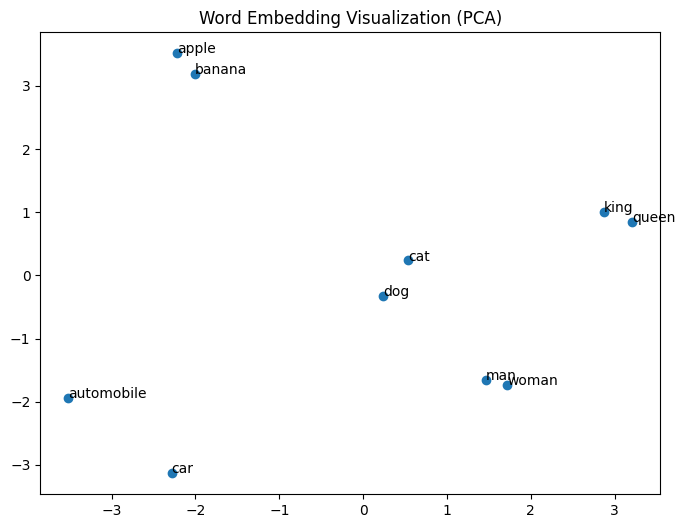

In [52]:
# Visualization using PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def visualize_words(words):

    vectors = []
    labels = []

    for w in words:
        vec, used = get_embedding_with_oov(w)
        if vec is not None:
            vectors.append(vec)
            labels.append(used)

    vectors = np.array(vectors)

    pca = PCA(n_components=2)
    reduced = pca.fit_transform(vectors)

    plt.figure(figsize=(8,6))
    plt.scatter(reduced[:,0], reduced[:,1])

    for i, word in enumerate(labels):
        plt.annotate(word, (reduced[i,0], reduced[i,1]))

    plt.title("Word Embedding Visualization (PCA)")
    plt.show()

visualize_words([
    "king","queen","man","woman",
    "dog","cat","car","automobile",
    "apple","banana"
])

### Why cosine similarity is useful?

Cosine similarity measures the angle between two embedding vectors rather than their magnitude. In word embedding space, semantic similarity is usually reflected by vector direction. Words with similar meanings tend to have vectors pointing in similar directions, producing cosine similarity values close to 1. Words that are unrelated have values closer to 0.

### About PCA plot:
In the PCA visualization, semantically related words such as “king” and “queen” or “dog” and “cat” appear closer together, while unrelated words such as “car” and “banana” are farther apart.

# Task 3 - Part 3: Designing a Novel Dissimilarity Metric

In [53]:
from numpy.linalg import norm

# Add new dissimilarity functions
def cosine_dissimilarity(vec1, vec2):
    return 1 - cosine_similarity(vec1, vec2)

def euclidean_distance(vec1, vec2):
    return norm(vec1 - vec2)

def custom_dissimilarity(vec1, vec2, alpha=0.7):
    cos_part = cosine_dissimilarity(vec1, vec2)
    euc_part = euclidean_distance(vec1, vec2)
    euc_part = euc_part / (1 + euc_part)   # normalize
    return alpha * cos_part + (1 - alpha) * euc_part


# Add one unified score function with toggle
def compute_score(word1, word2, metric="custom", alpha=0.7):
    vec1, used1 = get_embedding_with_oov(word1)
    vec2, used2 = get_embedding_with_oov(word2)

    if vec1 is None or vec2 is None:
        print("Cannot compute score because one or both words are unavailable.")
        return None

    if metric == "cosine":
        score = cosine_similarity(vec1, vec2)
        print(f"{word1} vs {word2} | cosine similarity = {score:.4f}")
    elif metric == "cosine_dissim":
        score = cosine_dissimilarity(vec1, vec2)
        print(f"{word1} vs {word2} | cosine dissimilarity = {score:.4f}")
    elif metric == "euclidean":
        score = euclidean_distance(vec1, vec2)
        print(f"{word1} vs {word2} | euclidean distance = {score:.4f}")
    elif metric == "custom":
        score = custom_dissimilarity(vec1, vec2, alpha=alpha)
        print(f"{word1} vs {word2} | custom dissimilarity = {score:.4f}")
    else:
        raise ValueError("metric must be one of: cosine, cosine_dissim, euclidean, custom")

    return score


compute_score("cat", "dog", metric="cosine")
compute_score("cat", "dog", metric="euclidean")
compute_score("cat", "table", metric="custom")

cat vs dog | cosine similarity = 0.8798
cat vs dog | euclidean distance = 2.6811
cat vs table | custom dissimilarity = 0.7410


np.float32(0.7410482)

In [54]:
# Rank words against one query word
def rank_words(query_word, candidate_words, metric="custom", alpha=0.7):
    query_vec, used_query = get_embedding_with_oov(query_word)
    if query_vec is None:
        print("Query word unavailable.")
        return []

    results = []

    for w in candidate_words:
        vec, used_w = get_embedding_with_oov(w)
        if vec is None:
            continue

        if metric == "cosine":
            score = cosine_similarity(query_vec, vec)
        elif metric == "cosine_dissim":
            score = cosine_dissimilarity(query_vec, vec)
        elif metric == "euclidean":
            score = euclidean_distance(query_vec, vec)
        elif metric == "custom":
            score = custom_dissimilarity(query_vec, vec, alpha=alpha)
        else:
            raise ValueError("metric must be one of: cosine, cosine_dissim, euclidean, custom")

        results.append((used_w, score))

    if metric == "cosine":
        results.sort(key=lambda x: x[1], reverse=True)
    else:
        results.sort(key=lambda x: x[1])

    return results


candidates = ["dog", "lion", "table", "tiger", "car", "kitten", "banana"]
print(rank_words("cat", candidates, metric="custom"))
print(rank_words("cat", candidates, metric="cosine"))

[('dog', np.float32(0.302638)), ('lion', np.float32(0.5308424)), ('kitten', np.float32(0.55436105)), ('tiger', np.float32(0.5724554)), ('table', np.float32(0.7410482)), ('car', np.float32(0.74359655)), ('banana', np.float32(0.76738083))]
[('dog', np.float32(0.8798076)), ('lion', np.float32(0.5955515)), ('kitten', np.float32(0.5580502)), ('tiger', np.float32(0.5415419)), ('car', np.float32(0.31097823)), ('table', np.float32(0.31008098)), ('banana', np.float32(0.2737714))]


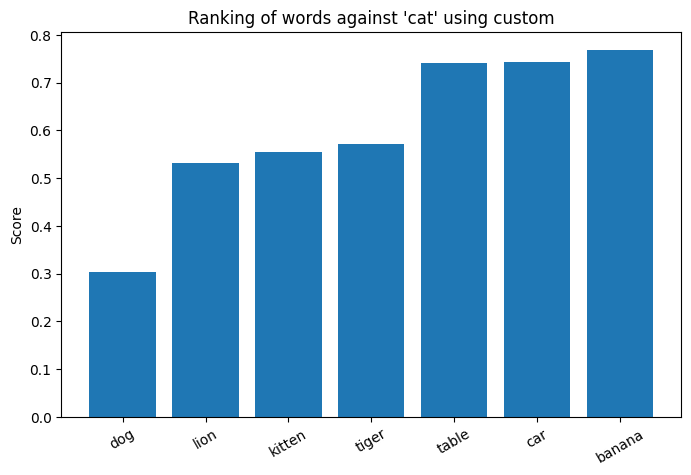

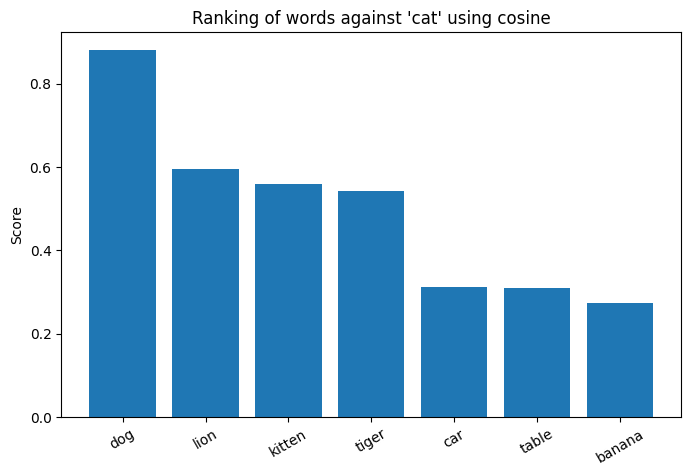

In [55]:
def plot_ranking(query_word, candidate_words, metric="custom", alpha=0.7):
    ranked = rank_words(query_word, candidate_words, metric=metric, alpha=alpha)

    words = [w for w, s in ranked]
    scores = [s for w, s in ranked]

    plt.figure(figsize=(8, 5))
    plt.bar(words, scores)
    plt.title(f"Ranking of words against '{query_word}' using {metric}")
    plt.ylabel("Score")
    plt.xticks(rotation=30)
    plt.show()

plot_ranking("cat", ["dog", "lion", "table", "tiger", "car", "kitten", "banana"], metric="custom")
plot_ranking("cat", ["dog", "lion", "table", "tiger", "car", "kitten", "banana"], metric="cosine")

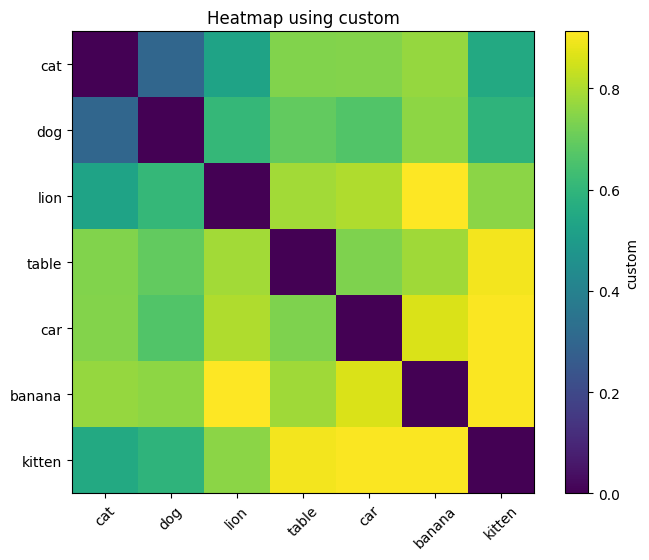

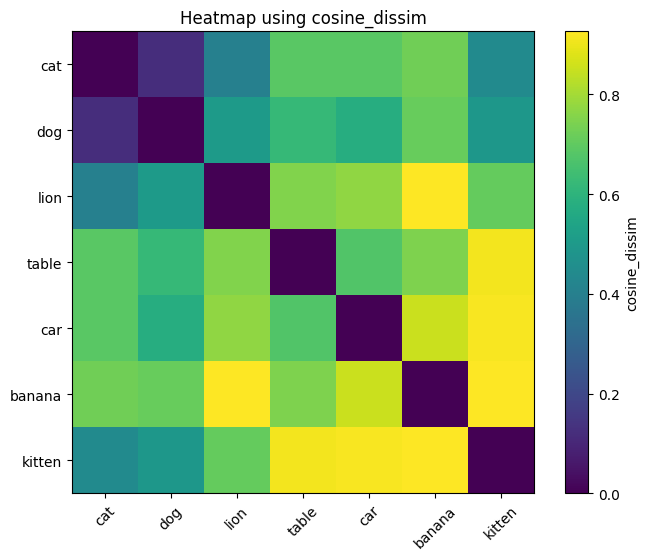

In [56]:
def build_matrix(words, metric="custom", alpha=0.7):
    valid_words = []
    vectors = []

    for w in words:
        vec, used = get_embedding_with_oov(w)
        if vec is not None:
            valid_words.append(used)
            vectors.append(vec)

    n = len(vectors)
    matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            if metric == "cosine":
                matrix[i, j] = cosine_similarity(vectors[i], vectors[j])
            elif metric == "cosine_dissim":
                matrix[i, j] = cosine_dissimilarity(vectors[i], vectors[j])
            elif metric == "euclidean":
                matrix[i, j] = euclidean_distance(vectors[i], vectors[j])
            elif metric == "custom":
                matrix[i, j] = custom_dissimilarity(vectors[i], vectors[j], alpha=alpha)
            else:
                raise ValueError("metric must be one of: cosine, cosine_dissim, euclidean, custom")

    return valid_words, matrix


def plot_heatmap(words, metric="custom", alpha=0.7):
    labels, matrix = build_matrix(words, metric=metric, alpha=alpha)

    plt.figure(figsize=(8, 6))
    plt.imshow(matrix, cmap="viridis")
    plt.colorbar(label=metric)
    plt.xticks(range(len(labels)), labels, rotation=45)
    plt.yticks(range(len(labels)), labels)
    plt.title(f"Heatmap using {metric}")
    plt.show()


words = ["cat", "dog", "lion", "table", "car", "banana", "kitten"]
plot_heatmap(words, metric="custom")
plot_heatmap(words, metric="cosine_dissim")

### Designing a Novel Dissimilarity Metric

In this part, I define a custom dissimilarity score that combines cosine dissimilarity and Euclidean distance:


$$D_{\text{custom}}(x,y) = \alpha (1 - \cos(x,y)) + (1-\alpha)\frac{\|x-y\|_2}{1+\|x-y\|_2}$$

The custom dissimilarity metric captures novelty and diversity better than cosine similarity alone because it combines cosine dissimilarity with Euclidean distance. Cosine similarity measures only the angle between two vectors, which reflects whether the words appear in similar semantic directions in the embedding space. However, two word embeddings can have a similar direction but still be located at different positions in the space, meaning they may not represent truly similar concepts. By incorporating Euclidean distance, the custom metric also considers the absolute spatial separation between embeddings, capturing how far apart the words are in the vector space. The Euclidean component is normalized to maintain a comparable scale with cosine dissimilarity. As a result, the combined metric reflects both directional similarity and positional difference, allowing it to identify words that are not only semantically different in direction but also distant in the embedding space. This provides a broader notion of novelty and diversity, making the metric more informative than cosine similarity alone.

cat vs dog | custom dissimilarity = 0.3026
cat vs table | custom dissimilarity = 0.7410


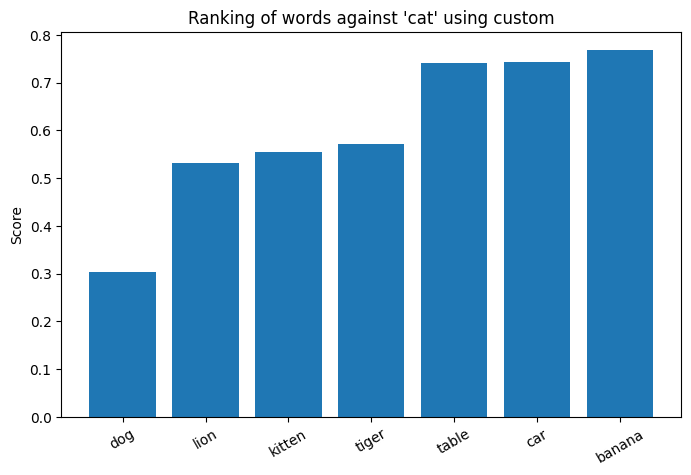

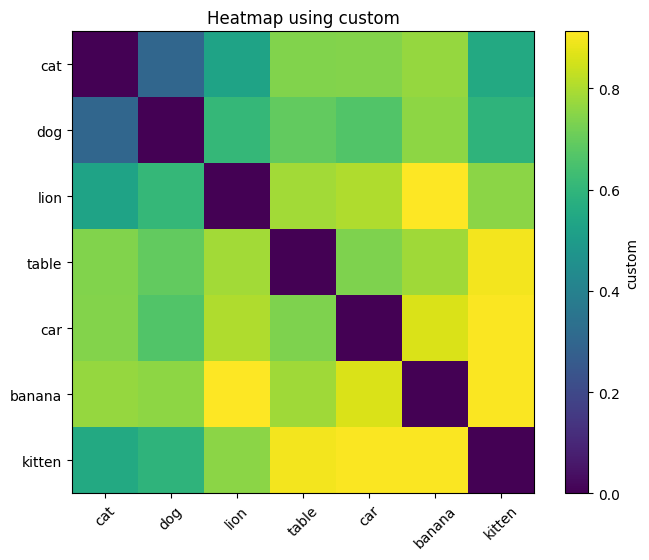

In [57]:
compute_score("cat", "dog", metric="custom")
compute_score("cat", "table", metric="custom")

plot_ranking("cat", ["dog", "lion", "table", "tiger", "car", "kitten", "banana"], metric="custom")

plot_heatmap(["cat", "dog", "lion", "table", "car", "banana", "kitten"], metric="custom")

### One sentence interpretate ranking
Under the custom metric, words such as “dog,” “lion,” and “kitten” rank closer to “cat,” while unrelated words such as “table” and “banana” receive larger dissimilarity scores.